In [12]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras

In [13]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)

Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)


In [14]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [15]:
x_train = x_train.reshape(-1, 28 * 28)
x_test = x_test.reshape(-1, 28 * 28)

print("New shape:", x_train.shape)

New shape: (60000, 784)


In [16]:
from sklearn.model_selection import train_test_split

x_train, x_val, y_train, y_val = train_test_split(
    x_train, y_train, test_size=0.1, random_state=42
)

In [17]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Dense(128, activation='relu', input_shape=(784,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')  # probability output
])

f:\ML\labpractice\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [19]:
history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(x_val, y_val)
)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9271 - loss: 0.2501 - val_accuracy: 0.9583 - val_loss: 0.1319
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9678 - loss: 0.1076 - val_accuracy: 0.9672 - val_loss: 0.1094
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9756 - loss: 0.0775 - val_accuracy: 0.9712 - val_loss: 0.0948
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9822 - loss: 0.0581 - val_accuracy: 0.9697 - val_loss: 0.0877
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9845 - loss: 0.0461 - val_accuracy: 0.9752 - val_loss: 0.0770
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9883 - loss: 0.0365 - val_accuracy: 0.9757 - val_loss: 0.0792
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9901 - loss: 0.0306 - val_accuracy: 0.9775 - val_loss: 0.0753
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9920 - loss: 0.0243 - 

In [20]:
test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 965us/step - accuracy: 0.9745 - loss: 0.1057
Test Accuracy: 0.9745000004768372


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


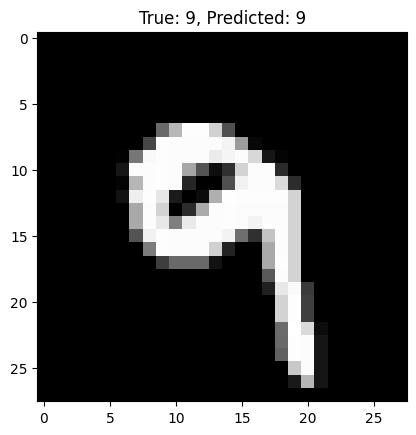

In [21]:
import random

index = random.randint(0, len(x_test)-1)

sample = x_test[index]
true_label = y_test[index]

prediction = model.predict(sample.reshape(1, -1))
predicted_label = np.argmax(prediction)

# Show image
plt.imshow(sample.reshape(28, 28), cmap='gray')
plt.title(f"True: {true_label}, Predicted: {predicted_label}")
plt.show()

In [23]:
for i, prob in enumerate(prediction[0]):
    print(f"Digit {i}: {prob:.8f}")

Digit 0: 0.00000000
Digit 1: 0.00000000
Digit 2: 0.00000000
Digit 3: 0.00039296
Digit 4: 0.00000023
Digit 5: 0.00068870
Digit 6: 0.00000000
Digit 7: 0.00000858
Digit 8: 0.00000231
Digit 9: 0.99890721


In [24]:
print("True:", true_label)
print("Predicted:", predicted_label)

True: 9
Predicted: 9
